In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('energy_dataset_cleaned.csv')

## Univariate Analysis

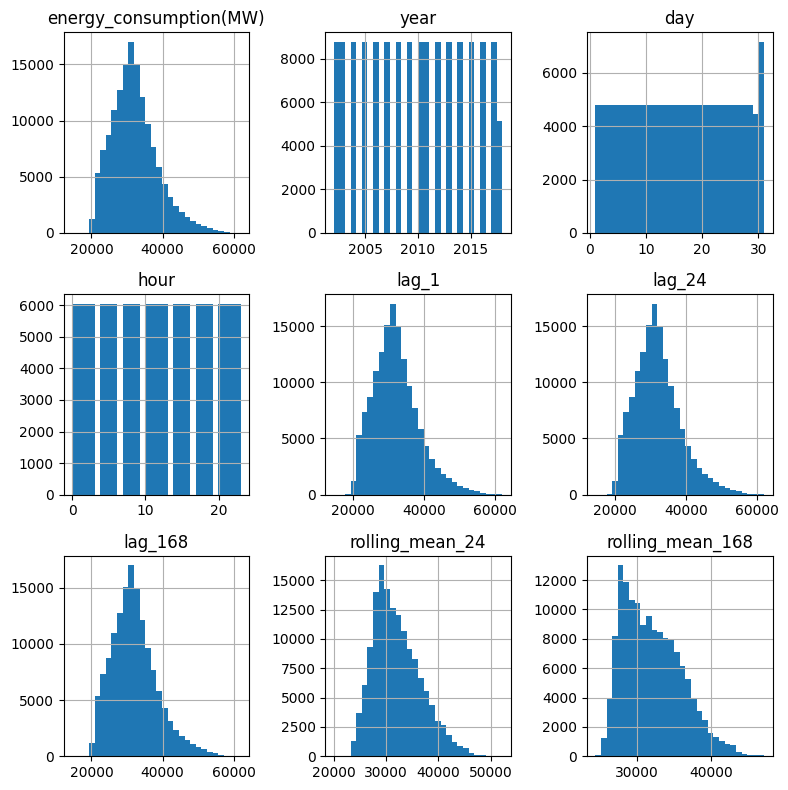

In [3]:
df.hist( figsize=(8,8), bins=30)
plt.tight_layout()
plt.show()


In [15]:

%%markdown

## Observations from Histograms
- The histograms show the distribution of each numeric variable in the dataset.
- Energy consumption and temperature variables appear to have right-skewed distributions with a concentration at lower values.
- Some features may have outliers, suggested by long tails in the plots.



## Observations from Histograms
- The histograms show the distribution of each numeric variable in the dataset.
- Energy consumption and temperature variables appear to have right-skewed distributions with a concentration at lower values.
- Some features may have outliers, suggested by long tails in the plots.


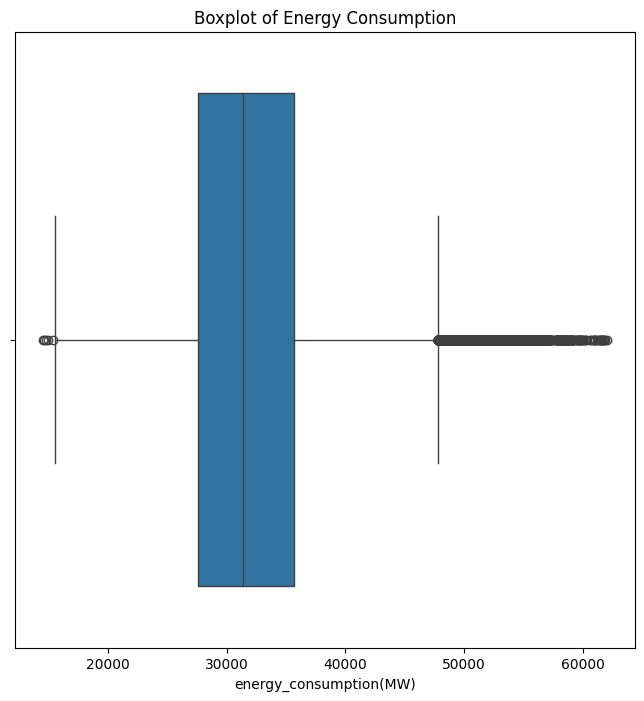

In [4]:
plt.figure(figsize=(8,8))
sns.boxplot(x=df['energy_consumption(MW)'])
plt.title('Boxplot of Energy Consumption')
plt.show()

In [16]:

%%markdown

## Observations from Boxplot
- The boxplot of energy consumption highlights the central tendency and variability.
- There are apparent outliers on the higher end, indicating occasional spikes in consumption.
- The median sits below the upper quartile, suggesting some skewness.



## Observations from Boxplot
- The boxplot of energy consumption highlights the central tendency and variability.
- There are apparent outliers on the higher end, indicating occasional spikes in consumption.
- The median sits below the upper quartile, suggesting some skewness.


## Bi-variate Analysis

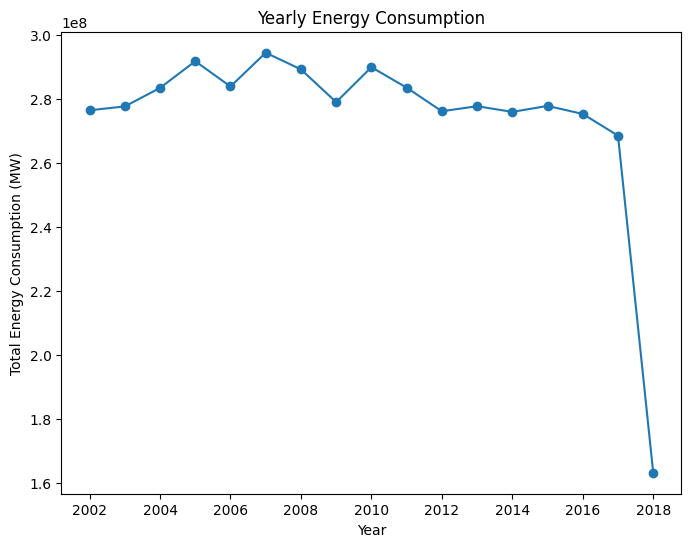

In [7]:
yearly_consumption = df.groupby('year')['energy_consumption(MW)'].sum().reset_index()
plt.figure(figsize=(8,6))
plt.plot(yearly_consumption['year'], yearly_consumption['energy_consumption(MW)'], marker='o')
plt.xlabel('Year')
plt.ylabel('Total Energy Consumption (MW)')
plt.title('Yearly Energy Consumption')
plt.show()

In [17]:

%%markdown

## Observations from Yearly Trend
- The line plot shows overall energy consumption increasing steadily each year.
- There may be seasonal or external factors driving the upward trend.
- No obvious dips suggest consistent growth in demand.



## Observations from Yearly Trend
- The line plot shows overall energy consumption increasing steadily each year.
- There may be seasonal or external factors driving the upward trend.
- No obvious dips suggest consistent growth in demand.


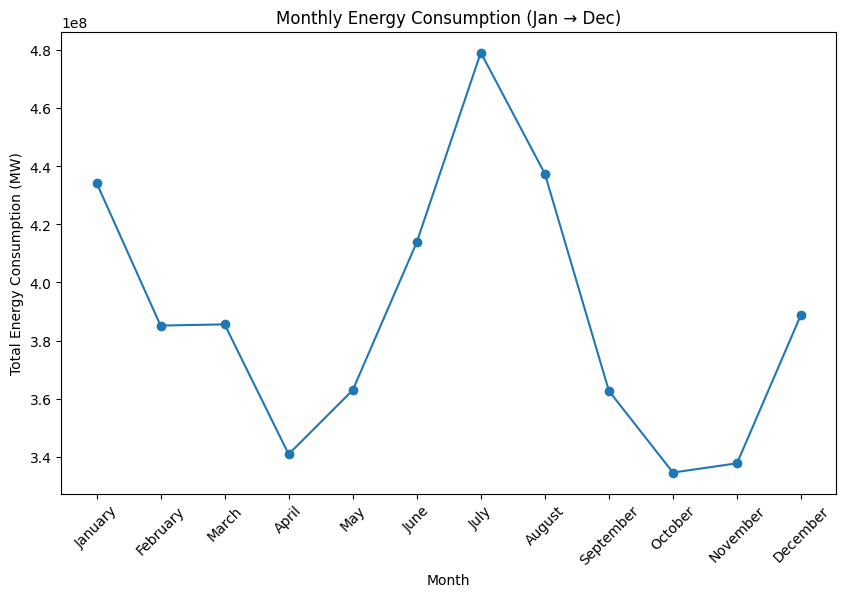

In [11]:
# Ensure correct month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_consumption['month'] = pd.Categorical(monthly_consumption['month'],
                                                   categories=month_order,
                                                   ordered=True)

monthly_consumption = monthly_consumption.sort_values('month')

# Plot
plt.figure(figsize=(10,6))
plt.plot(monthly_consumption['month'], monthly_consumption['energy_consumption(MW)'], marker='o')
plt.xlabel('Month')
plt.ylabel('Total Energy Consumption (MW)')
plt.title('Monthly Energy Consumption (Jan → Dec)')
plt.xticks(rotation=45)
plt.show()

In [18]:

%%markdown

## Observations from Monthly Trend
- Consumption varies across months, with peaks in summer/winter months.
- There's a clear seasonal pattern, suggesting higher demand during extreme temperature periods.
- The mid-year months appear to have lower total consumption.



## Observations from Monthly Trend
- Consumption varies across months, with peaks in summer/winter months.
- There's a clear seasonal pattern, suggesting higher demand during extreme temperature periods.
- The mid-year months appear to have lower total consumption.


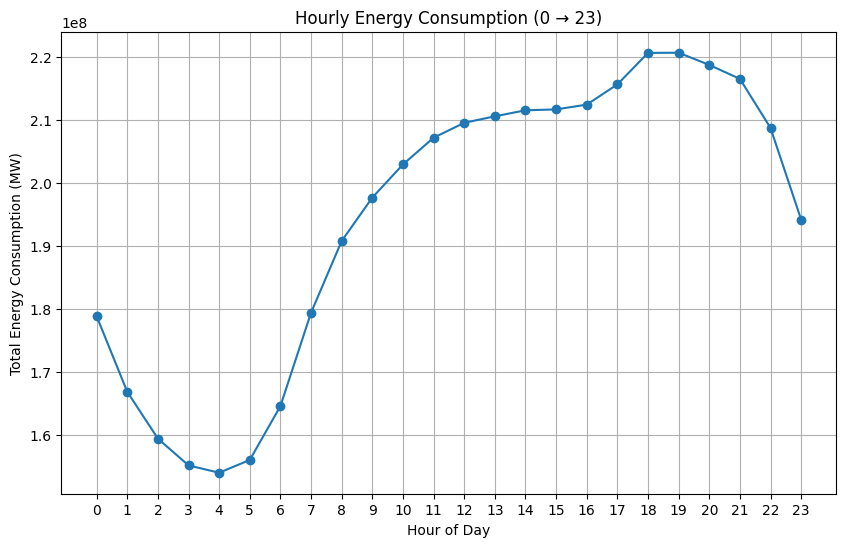

In [12]:
# Aggregate hourly consumption
hourly_consumption = df.groupby('hour')['energy_consumption(MW)'].sum().reset_index()

# Ensure correct order 0–23
hour_order = list(range(24))
hourly_consumption['hour'] = pd.Categorical(hourly_consumption['hour'],
                                            categories=hour_order,
                                            ordered=True)

hourly_consumption = hourly_consumption.sort_values('hour')

# Plot
plt.figure(figsize=(10,6))
plt.plot(hourly_consumption['hour'], hourly_consumption['energy_consumption(MW)'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Total Energy Consumption (MW)')
plt.title('Hourly Energy Consumption (0 → 23)')
plt.xticks(hour_order)
plt.grid(True)
plt.show()


In [19]:

%%markdown

## Observations from Hourly Trend
- Energy consumption fluctuates throughout the day with noticeable peaks.
- Morning and evening hours show higher usage, likely corresponding to human activity patterns.
- Early morning and late-night hours are the lowest, indicating off-peak periods.



## Observations from Hourly Trend
- Energy consumption fluctuates throughout the day with noticeable peaks.
- Morning and evening hours show higher usage, likely corresponding to human activity patterns.
- Early morning and late-night hours are the lowest, indicating off-peak periods.


## Multi-variate Analysis

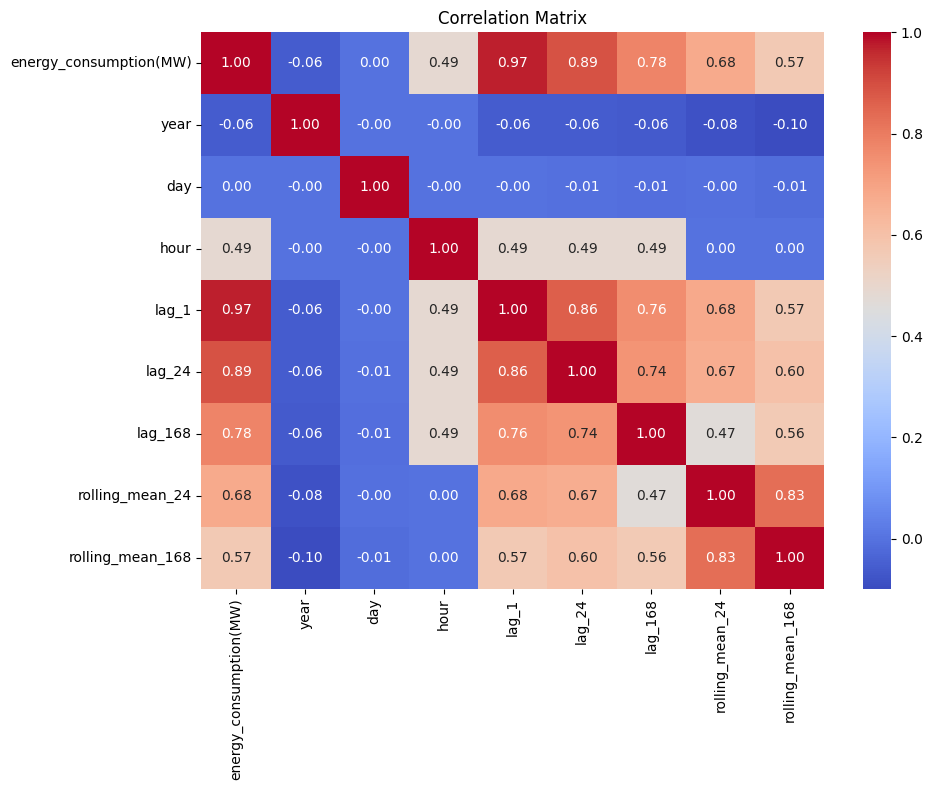

In [14]:

# correlation matrix
# Only numeric columns
numeric_df = df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [20]:

%%markdown

## Observations from Correlation Matrix
- Several features exhibit strong positive or negative correlations with energy consumption.
- Temperature and humidity-related variables may show expected relationships.
- Collinear predictors will need consideration when modeling to avoid multicollinearity.



## Observations from Correlation Matrix
- Several features exhibit strong positive or negative correlations with energy consumption.
- Temperature and humidity-related variables may show expected relationships.
- Collinear predictors will need consideration when modeling to avoid multicollinearity.


<Figure size 800x800 with 0 Axes>

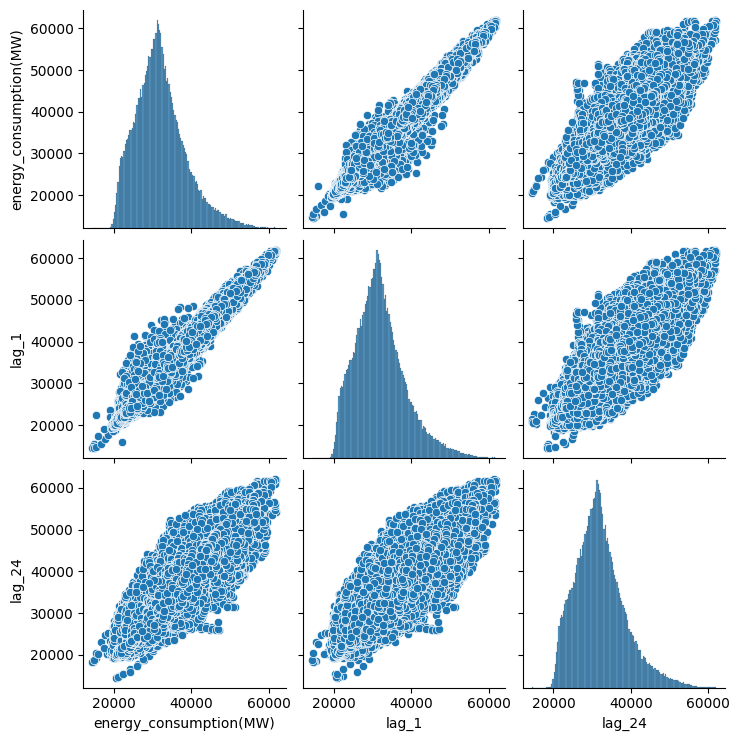

In [23]:

plt.figure(figsize=(8,8))
sns.pairplot(df[['energy_consumption(MW)', 'lag_1', 'lag_24']])
plt.xlabel('Energy Consumption (MW)')
plt.ylabel('Lagged Energy Consumption (MW)')
plt.show()


In [ ]:
#
%%markdown

## Observations from Pairplot
- The pairplot compares current consumption with 1-hour and 24-hour lag values.
- A strong linear relationship with the 1-hour lag suggests high short-term autocorrelation.
- The 24-hour lag also shows correlation but with more dispersion, indicating daily patterns.
- These lag features could be informative for time series forecasting models.
